# GOAT algorithm for a closed system


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import gates, qeye, sigmax, sigmay, sigmaz, tensor
import qutip as qt
from qutip_qoc import Objective, optimize_pulses

def fidelity(gate, target_gate):
    """
    Fidelity used for unitary gates in qutip-qtrl and qutip-qoc
    """
    return np.abs(gate.overlap(target_gate) / target_gate.norm())


## Problem setup


In [3]:
omega = 0.1  # energy splitting
sx, sy, sz = sigmax(), sigmay(), sigmaz()

Hd = 1 / 2 * omega * sz
Hc = [sx, sy, sz]

# objective for optimization
initial_gate = qeye(2)
target_gate = gates.hadamard_transform()

times = np.linspace(0, np.pi / 2, 250)




In [4]:
# problem setup: slow effective model for controlled bring-up

import numpy as np
import qutip as qt
from qutip import tensor, qeye, sigmax, sigmay, sigmaz

MHz=2*np.pi*1e6

A1=95*MHz
A2=9*MHz

I=qeye(2)
sx=sigmax()
sy=sigmay()
sz=sigmaz()

def op3(a,b,c):
    return tensor(a,b,c)

# ordering: [electron,nucleus1,nucleus2]
Sx=op3(sx,I,I)
Sy=op3(sy,I,I)
Sz=op3(sz,I,I)

Ix1=op3(I,sx,I)
Iy1=op3(I,sy,I)
Iz1=op3(I,sz,I)

Ix2=op3(I,I,sx)
Iy2=op3(I,I,sy)
Iz2=op3(I,I,sz)

# slow effective drift
Hd=A1*Sz*Iz1+A2*Sz*Iz2

# simple effective controls
Hx=Sx
Hy=Sy
Hc=[Hx,Hy]

initial_gate=qt.qeye([2,2,2])

UXX=(1/2)*qt.Qobj(np.array([
    [1,0,0,1,1,0,0,-1],
    [0,1,1,0,0,1,-1,0],
    [0,1,1,0,0,-1,1,0],
    [1,0,0,1,-1,0,0,1],
    [1,0,0,-1,1,0,0,1],
    [0,1,-1,0,0,1,1,0],
    [0,-1,1,0,0,1,1,0],
    [-1,0,0,1,1,0,0,1],
],dtype=complex),dims=[[2,2,2],[2,2,2]])

target_gate=UXX

T=4e-6
times=np.linspace(0,T,1000)


# carrier choices for the fixed-frequency GOAT ansatz

w1=A1
w2=A2
w3=A1+A2

print("w1/2π [MHz]:",w1/(2*np.pi*1e6))
print("w2/2π [MHz]:",w2/(2*np.pi*1e6))
print("w3/2π [MHz]:",w3/(2*np.pi*1e6))

w1/2π [MHz]: 95.00000000000001
w2/2π [MHz]: 9.0
w3/2π [MHz]: 104.0


## Guess


Fidelity: 0.4995468099334273


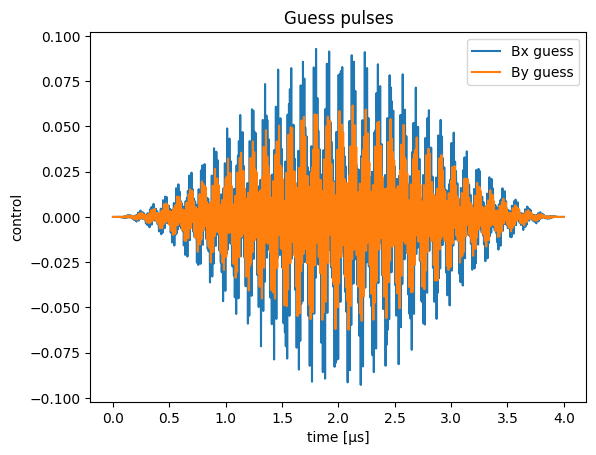

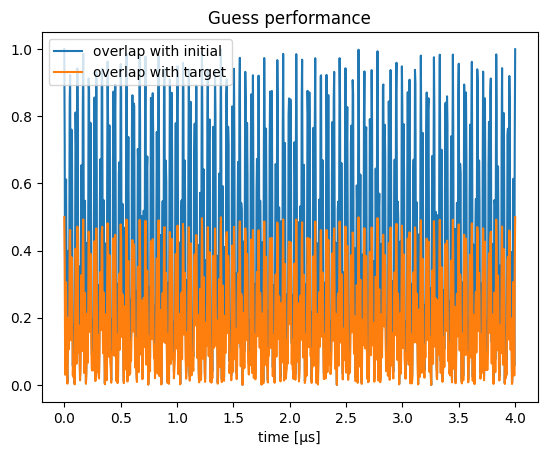

In [5]:
"""
goat_guess = [1, 1] # [A, w]
guess_pulse = goat_guess[0] * np.sin(goat_guess[1] * times) # A*sin(w*t)

H_guess = [Hd] + [[hc, guess_pulse] for hc in Hc] 
evolution_guess = qt.sesolve(H_guess, initial_gate, times)

print('Fidelity: ', fidelity(evolution_guess.states[-1], target_gate))

plt.plot(times, [fidelity(gate, initial_gate) for gate in evolution_guess.states], label="Overlap with initial gate")
plt.plot(times, [fidelity(gate, target_gate) for gate in evolution_guess.states], label="Overlap with target gate")
plt.title("Guess performance")
plt.xlabel('Time')
plt.legend()
plt.show()
"""

# guess: 3 fixed carriers with sin^2 envelope

def env(t):
    return np.sin(np.pi*t/T)**2

goat_guess_x=[0.06,0,0.03,0,0.02,0]
goat_guess_y=[0.04,np.pi/2,0.02,0,0.01,np.pi/2]

def u_fixed3(t,c):
    A1x,p1,A2x,p2,A3x,p3=c
    return env(t)*(
        A1x*np.sin(w1*t+p1)+
        A2x*np.sin(w2*t+p2)+
        A3x*np.sin(w3*t+p3)
    )

guess_pulse_x=np.array([u_fixed3(t,goat_guess_x) for t in times])
guess_pulse_y=np.array([u_fixed3(t,goat_guess_y) for t in times])

H_guess=[
    Hd,
    [Hc[0],guess_pulse_x],
    [Hc[1],guess_pulse_y],
]

evolution_guess=qt.sesolve(
    H_guess,
    initial_gate,
    times,
    options={"nsteps":200000}
)

print("Fidelity:",fidelity(evolution_guess.states[-1],target_gate))

plt.plot(times*1e6,guess_pulse_x,label="Bx guess")
plt.plot(times*1e6,guess_pulse_y,label="By guess")
plt.xlabel("time [µs]")
plt.ylabel("control")
plt.title("Guess pulses")
plt.legend()
plt.show()

plt.plot(times*1e6,[fidelity(gate,initial_gate) for gate in evolution_guess.states],label="overlap with initial")
plt.plot(times*1e6,[fidelity(gate,target_gate) for gate in evolution_guess.states],label="overlap with target")
plt.xlabel("time [µs]")
plt.title("Guess performance")
plt.legend()
plt.show()

## GOAT algorithm


In [6]:
# GOAT algorithm: fixed 3-carrier ansatz with envelope

def env(t):
    return np.sin(np.pi*t/T)**2

def denv_dt(t):
    return (np.pi/T)*np.sin(2*np.pi*t/T)

def u_fixed3(t,c):
    A1x,p1,A2x,p2,A3x,p3=c

    s1=np.sin(w1*t+p1)
    s2=np.sin(w2*t+p2)
    s3=np.sin(w3*t+p3)

    return env(t)*(A1x*s1+A2x*s2+A3x*s3)

def grad_u_fixed3(t,c,idx):
    A1x,p1,A2x,p2,A3x,p3=c

    e=env(t)
    de=denv_dt(t)

    s1=np.sin(w1*t+p1)
    s2=np.sin(w2*t+p2)
    s3=np.sin(w3*t+p3)

    c1=np.cos(w1*t+p1)
    c2=np.cos(w2*t+p2)
    c3=np.cos(w3*t+p3)

    if idx==0:
        return e*s1
    if idx==1:
        return e*A1x*c1
    if idx==2:
        return e*s2
    if idx==3:
        return e*A2x*c2
    if idx==4:
        return e*s3
    if idx==5:
        return e*A3x*c3
    if idx==6:
        return de*(A1x*s1+A2x*s2+A3x*s3)+e*(A1x*w1*c1+A2x*w2*c2+A3x*w3*c3)

H=[Hd]+[[hc,u_fixed3,{"grad":grad_u_fixed3}] for hc in Hc]

### a) not optimized over time


Infidelity: 0.5448163983389459
optimized_params: [[0.06, 0.0, 0.03, 0.0, 0.02, 0.0], [0.04, 1.5707963267948966, 0.02, 0.0, 0.01, 1.5707963267948966]]


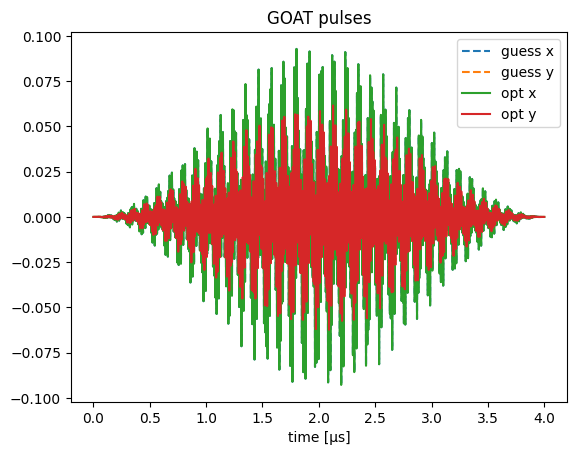

In [7]:
control_params={
    "x":{
        "guess":goat_guess_x,
        "bounds":[
            (-0.2,0.2),(-np.pi,np.pi),
            (-0.2,0.2),(-np.pi,np.pi),
            (-0.2,0.2),(-np.pi,np.pi),
        ],
    },
    "y":{
        "guess":goat_guess_y,
        "bounds":[
            (-0.2,0.2),(-np.pi,np.pi),
            (-0.2,0.2),(-np.pi,np.pi),
            (-0.2,0.2),(-np.pi,np.pi),
        ],
    },
}

res_goat=optimize_pulses(
    objectives=Objective(initial_gate,H,target_gate),
    control_parameters=control_params,
    tlist=times,
    algorithm_kwargs={
        "alg":"GOAT",
        "fid_err_targ":1e-3,
    },
    integrator_kwargs={
        "nsteps":200000
    }
)

print("Infidelity:",res_goat.infidelity)
print("optimized_params:",res_goat.optimized_params)

plt.plot(times*1e6,guess_pulse_x,"--",label="guess x")
plt.plot(times*1e6,guess_pulse_y,"--",label="guess y")
plt.plot(times*1e6,res_goat.optimized_controls[0],label="opt x")
plt.plot(times*1e6,res_goat.optimized_controls[1],label="opt y")
plt.xlabel("time [µs]")
plt.title("GOAT pulses")
plt.legend()
plt.show()

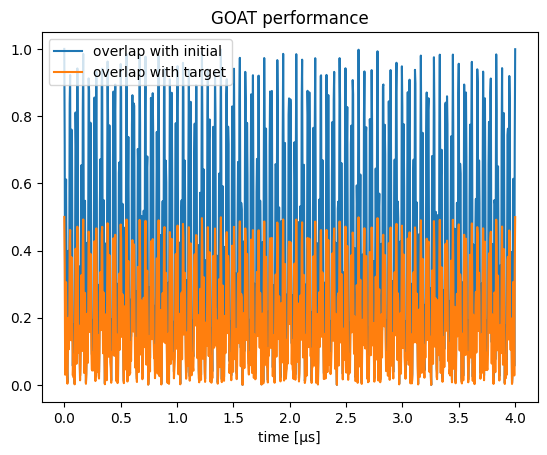

In [9]:
H_result=[
    Hd,
    [Hc[0],np.array(res_goat.optimized_controls[0])],
    [Hc[1],np.array(res_goat.optimized_controls[1])],
]

evolution=qt.sesolve(
    H_result,
    initial_gate,
    times,
    options={"nsteps":200000}
)

plt.plot(times*1e6,[fidelity(gate,initial_gate) for gate in evolution.states],label="overlap with initial")
plt.plot(times*1e6,[fidelity(gate,target_gate) for gate in evolution.states],label="overlap with target")
plt.xlabel("time [µs]")
plt.title("GOAT performance")
plt.legend()
plt.show()

### b) optimized over time


Infidelity: 0.5441723697636254
optimized_params: [[0.06, 9.247229914146083e-39, 0.03, -2.553359971866747e-39, 0.02, 3.3025821121947754e-39], [0.04, 1.5707963267948966, 0.02, 1.3974562325978588e-39, 0.01, 1.5707963267948966], [3.999910987270778e-06]]


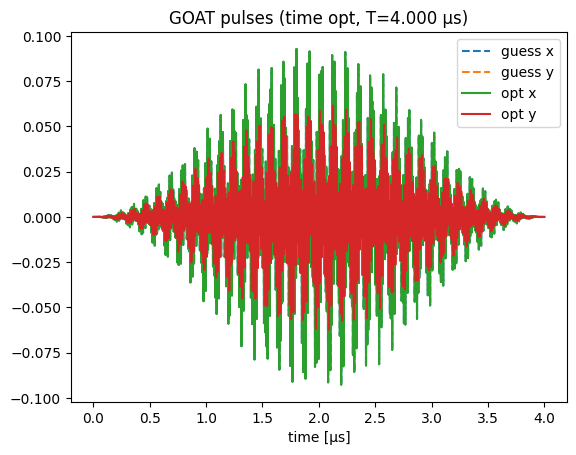

In [10]:
control_params_time={
    "x":{
        "guess":goat_guess_x,
        "bounds":[
            (-0.2,0.2),(-np.pi,np.pi),
            (-0.2,0.2),(-np.pi,np.pi),
            (-0.2,0.2),(-np.pi,np.pi),
        ],
    },
    "y":{
        "guess":goat_guess_y,
        "bounds":[
            (-0.2,0.2),(-np.pi,np.pi),
            (-0.2,0.2),(-np.pi,np.pi),
            (-0.2,0.2),(-np.pi,np.pi),
        ],
    },
    "__time__":{"guess":T,"bounds":[(1e-6,8e-6)]},
}

res_goat_time=optimize_pulses(
    objectives=Objective(initial_gate,H,target_gate),
    control_parameters=control_params_time,
    tlist=times,
    algorithm_kwargs={
        "alg":"GOAT",
        "fid_err_targ":1e-3,
    },
    integrator_kwargs={
        "nsteps":200000
    }
)

print("Infidelity:",res_goat_time.infidelity)
print("optimized_params:",res_goat_time.optimized_params)

T_opt=res_goat_time.optimized_params[-1][0]

plt.plot(times*1e6,guess_pulse_x,"--",label="guess x")
plt.plot(times*1e6,guess_pulse_y,"--",label="guess y")
plt.plot(times*1e6,res_goat_time.optimized_controls[0],label="opt x")
plt.plot(times*1e6,res_goat_time.optimized_controls[1],label="opt y")
plt.xlabel("time [µs]")
plt.title(f"GOAT pulses (time opt, T={T_opt*1e6:.3f} µs)")
plt.legend()
plt.show()

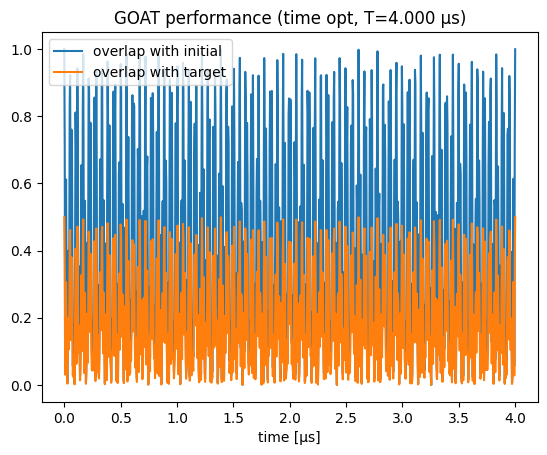

In [12]:
T_opt=res_goat_time.optimized_params[-1][0]

H_result_time=[
    Hd,
    [Hc[0],np.array(res_goat_time.optimized_controls[0])],
    [Hc[1],np.array(res_goat_time.optimized_controls[1])],
]

evolution_time=qt.sesolve(
    H_result_time,
    initial_gate,
    times,
    options={"nsteps":200000}
)

times_rescaled=np.linspace(0,T_opt,len(times))

plt.plot(times_rescaled*1e6,[fidelity(gate,initial_gate) for gate in evolution_time.states],label="overlap with initial")
plt.plot(times_rescaled*1e6,[fidelity(gate,target_gate) for gate in evolution_time.states],label="overlap with target")
plt.xlabel("time [µs]")
plt.title(f"GOAT performance (time opt, T={T_opt*1e6:.3f} µs)")
plt.legend()
plt.show()

## Global optimization


Infidelity: 0.5115089495648283
optimized_params: [[0.13494451579122563, -0.17107677857753656, 0.2, 0.1824436873606986, 0.2, 0.41444049699727603], [-0.017711729876145277, 1.9690245266898647, -0.025719947895406714, -0.060468466985172276, -0.2, 1.4748133960033156], [1e-06]]


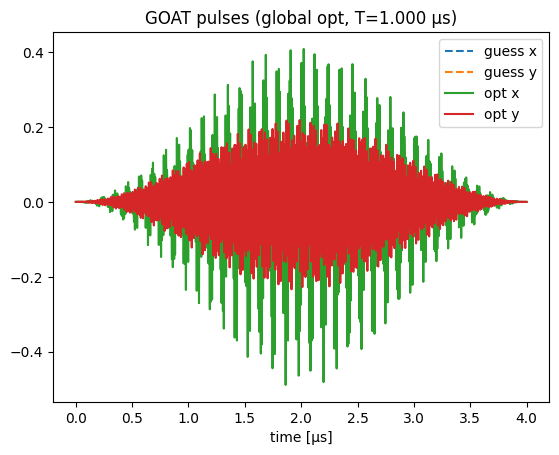

In [13]:
control_params_global={
    "x":{
        "guess":goat_guess_x,
        "bounds":[
            (-0.2,0.2),(-np.pi,np.pi),
            (-0.2,0.2),(-np.pi,np.pi),
            (-0.2,0.2),(-np.pi,np.pi),
        ],
    },
    "y":{
        "guess":goat_guess_y,
        "bounds":[
            (-0.2,0.2),(-np.pi,np.pi),
            (-0.2,0.2),(-np.pi,np.pi),
            (-0.2,0.2),(-np.pi,np.pi),
        ],
    },
    "__time__":{"guess":T,"bounds":[(1e-6,8e-6)]},
}

res_goat_global=optimize_pulses(
    objectives=Objective(initial_gate,H,target_gate),
    control_parameters=control_params_global,
    tlist=times,
    algorithm_kwargs={
        "alg":"GOAT",
        "fid_err_targ":1e-3,
    },
    optimizer_kwargs={
        "method":"basinhopping",
        "niter":10
    },
    integrator_kwargs={
        "nsteps":200000
    }
)

print("Infidelity:",res_goat_global.infidelity)
print("optimized_params:",res_goat_global.optimized_params)

T_global=res_goat_global.optimized_params[-1][0]

plt.plot(times*1e6,guess_pulse_x,"--",label="guess x")
plt.plot(times*1e6,guess_pulse_y,"--",label="guess y")
plt.plot(times*1e6,res_goat_global.optimized_controls[0],label="opt x")
plt.plot(times*1e6,res_goat_global.optimized_controls[1],label="opt y")
plt.xlabel("time [µs]")
plt.title(f"GOAT pulses (global opt, T={T_global*1e6:.3f} µs)")
plt.legend()
plt.show()

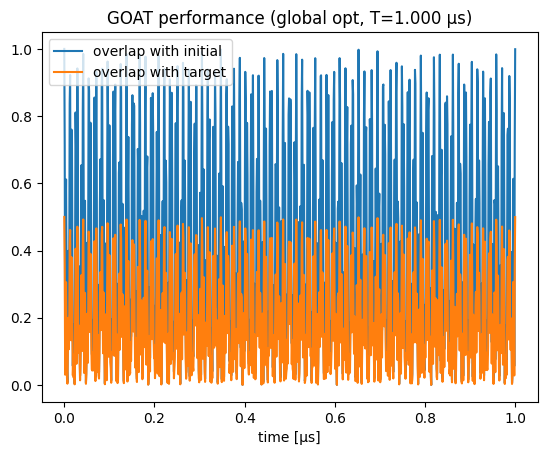

In [14]:
T_global=res_goat_global.optimized_params[-1][0]

H_result_global=[
    Hd,
    [Hc[0],np.array(res_goat_global.optimized_controls[0])],
    [Hc[1],np.array(res_goat_global.optimized_controls[1])],
]

evolution_global=qt.sesolve(
    H_result_global,
    initial_gate,
    times,
    options={"nsteps":200000}
)

times_rescaled=np.linspace(0,T_global,len(times))

plt.plot(times_rescaled*1e6,[fidelity(gate,initial_gate) for gate in evolution_global.states],label="overlap with initial")
plt.plot(times_rescaled*1e6,[fidelity(gate,target_gate) for gate in evolution_global.states],label="overlap with target")
plt.xlabel("time [µs]")
plt.title(f"GOAT performance (global opt, T={T_global*1e6:.3f} µs)")
plt.legend()
plt.show()

## Comparison


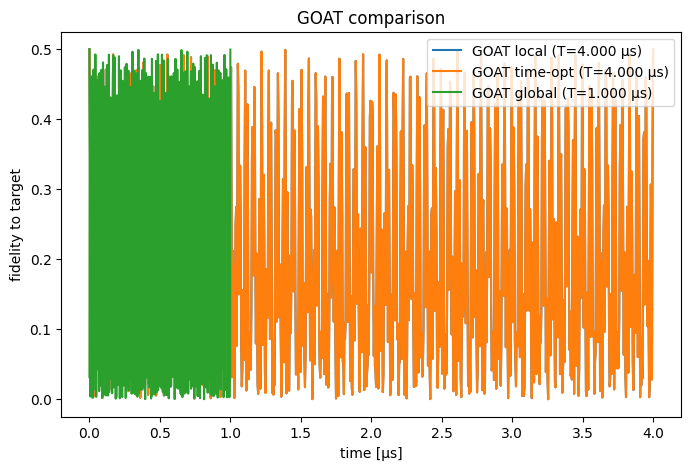

local infidelity:     0.5448163983389459
time-opt infidelity:  0.5441723697636254
global infidelity:    0.5115089495648283


In [15]:
plt.figure(figsize=(8,5))

plt.plot(times*1e6,[fidelity(gate,target_gate) for gate in evolution.states],
         label=f"GOAT local (T={T*1e6:.3f} µs)")

plt.plot(np.linspace(0,T_opt,len(times))*1e6,
         [fidelity(gate,target_gate) for gate in evolution_time.states],
         label=f"GOAT time-opt (T={T_opt*1e6:.3f} µs)")

plt.plot(np.linspace(0,T_global,len(times))*1e6,
         [fidelity(gate,target_gate) for gate in evolution_global.states],
         label=f"GOAT global (T={T_global*1e6:.3f} µs)")

plt.xlabel("time [µs]")
plt.ylabel("fidelity to target")
plt.title("GOAT comparison")
plt.legend()
plt.show()

print("local infidelity:    ",res_goat.infidelity)
print("time-opt infidelity: ",res_goat_time.infidelity)
print("global infidelity:   ",res_goat_global.infidelity)

## Spectrum of optimized pulses

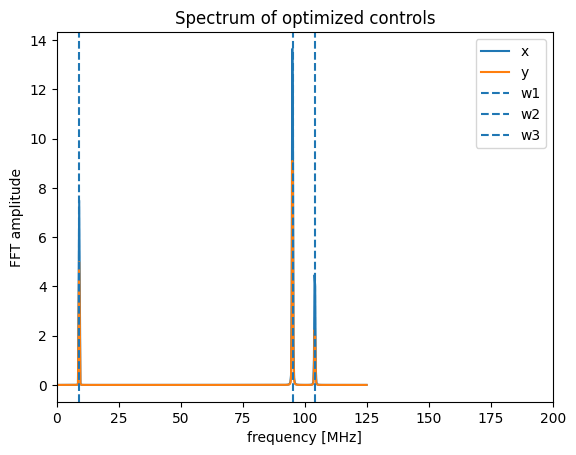

In [16]:
# spectrum of local optimized controls

dt=times[1]-times[0]
freqs=np.fft.rfftfreq(len(times),d=dt)/(1e6)
spec_x=np.abs(np.fft.rfft(np.array(res_goat.optimized_controls[0])))
spec_y=np.abs(np.fft.rfft(np.array(res_goat.optimized_controls[1])))

plt.plot(freqs,spec_x,label="x")
plt.plot(freqs,spec_y,label="y")
plt.axvline(w1/(2*np.pi*1e6),ls="--",label="w1")
plt.axvline(w2/(2*np.pi*1e6),ls="--",label="w2")
plt.axvline(w3/(2*np.pi*1e6),ls="--",label="w3")
plt.xlim(0,200)
plt.xlabel("frequency [MHz]")
plt.ylabel("FFT amplitude")
plt.title("Spectrum of optimized controls")
plt.legend()
plt.show()

## Validation


In [36]:
assert res_goat.infidelity < 0.001
assert fidelity(evolution.states[-1], target_gate) > 1-0.001

assert res_goat_time.infidelity < 0.001
assert fidelity(evolution_time.states[-1], target_gate) > 1-0.001

assert res_goat_global.infidelity < 0.001
assert fidelity(evolution_global.states[-1], target_gate) > 1-0.001


AssertionError: 

In [13]:
qt.about()



QuTiP: Quantum Toolbox in Python
Copyright (c) QuTiP team 2011 and later.
Current admin team: Alexander Pitchford, Nathan Shammah, Shahnawaz Ahmed, Neill Lambert, Eric Giguère, Boxi Li, Simon Cross, Asier Galicia, Paul Menczel, and Patrick Hopf.
Board members: Daniel Burgarth, Robert Johansson, Anton F. Kockum, Franco Nori and Will Zeng.
Original developers: R. J. Johansson & P. D. Nation.
Previous lead developers: Chris Granade & A. Grimsmo.
Currently developed through wide collaboration. See https://github.com/qutip for details.

QuTiP Version:      5.2.3
Numpy Version:      1.26.4
Scipy Version:      1.17.1
Cython Version:     None
Matplotlib Version: 3.10.8
Python Version:     3.11.15
Number of CPUs:     8
BLAS Info:          Accelerate
INTEL MKL Ext:      None
Platform Info:      Darwin (arm64)
Installation path:  /Users/johnkraus/anaconda3/envs/goat_env/lib/python3.11/site-packages/qutip

Installed QuTiP family packages
-------------------------------

qutip-qtrl: 0.1.5
qutip-ja